# "EDA"
---


# 1. Описание датасета





Датасет: Superstore Sales

Датасет содержит информацию о продажах крупного американского розничного магазина.
В нём представлены заказы клиентов с 2017 года по различным категориям товаров.

Основные признаки:


* `Order_ID` - уникальный
идентификатор заказа
* `Order_Date, Ship_Date` - даты заказа и отгрузки
* `Ship_Mode` - способ доставки (Second Class, Standard Class, First Class, Same Day)
* `Segment` - сегмент покупателя (Consumer, Corporate, Home Office)
* `Region`, `State`, `City` - географические данные
* `Category`, `Sub_Category` - категория и подкатегория товара
* `Product_Name` - название товара
* `Sales` - сумма продажи (целевая переменная)




# 2. Загрузка и предварительный просмотр

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings
import kagglehub
import os

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

path = kagglehub.dataset_download("bhanupratapbiswas/superstore-sales")
print("Path to dataset files:", path)

print(os.listdir(path))


100%|██████████| 478k/478k [00:00<00:00, 63.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bhanupratapbiswas/superstore-sales/versions/1
['superstore_final_dataset (1).csv']


In [2]:
filepath = os.path.join(path, 'superstore_final_dataset (1).csv')

with open(filepath, 'r', encoding='latin-1') as f:
  content = f.read()

df = pd.read_csv(io.StringIO(content))

print(f"Датасет загружен: {df.shape[0]} строк, {df.shape[1]} столбцов")
print()
display(df.head())

Датасет загружен: 9800 строк, 18 столбцов



,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [3]:
print("\nТипы данных:")
print(df.dtypes)


Типы данных:
Row_ID             int64
Order_ID          object
Order_Date        object
Ship_Date         object
Ship_Mode         object
Customer_ID       object
Customer_Name     object
Segment           object
Country           object
City              object
State             object
Postal_Code      float64
Region            object
Product_ID        object
Category          object
Sub_Category      object
Product_Name      object
Sales            float64
dtype: object


In [4]:
print("\nОбщая информация о данных (типы, количество не-null значений):")
df.info()


Общая информация о данных (типы, количество не-null значений):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   o

In [5]:
print("\nОсновная статистика по числовым столбцам:")
display(df.describe())


Основная статистика по числовым столбцам:


,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [6]:
print("=" * 60)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("=" * 60)
display(df.describe(include='object'))

ОПИСАТЕЛЬНАЯ СТАТИСТИКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ


,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub_Category,Product_Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,5/9/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


`describe(include='object')` показывает для каждого текстового столбца:
количество непустых значений, число уникальных значений, наиболее частое
значение (top) и его частоту (freq).

Визуализируем, как заказы распределены относительно сегмента покупателя, региона, категории товара и способа доставки.

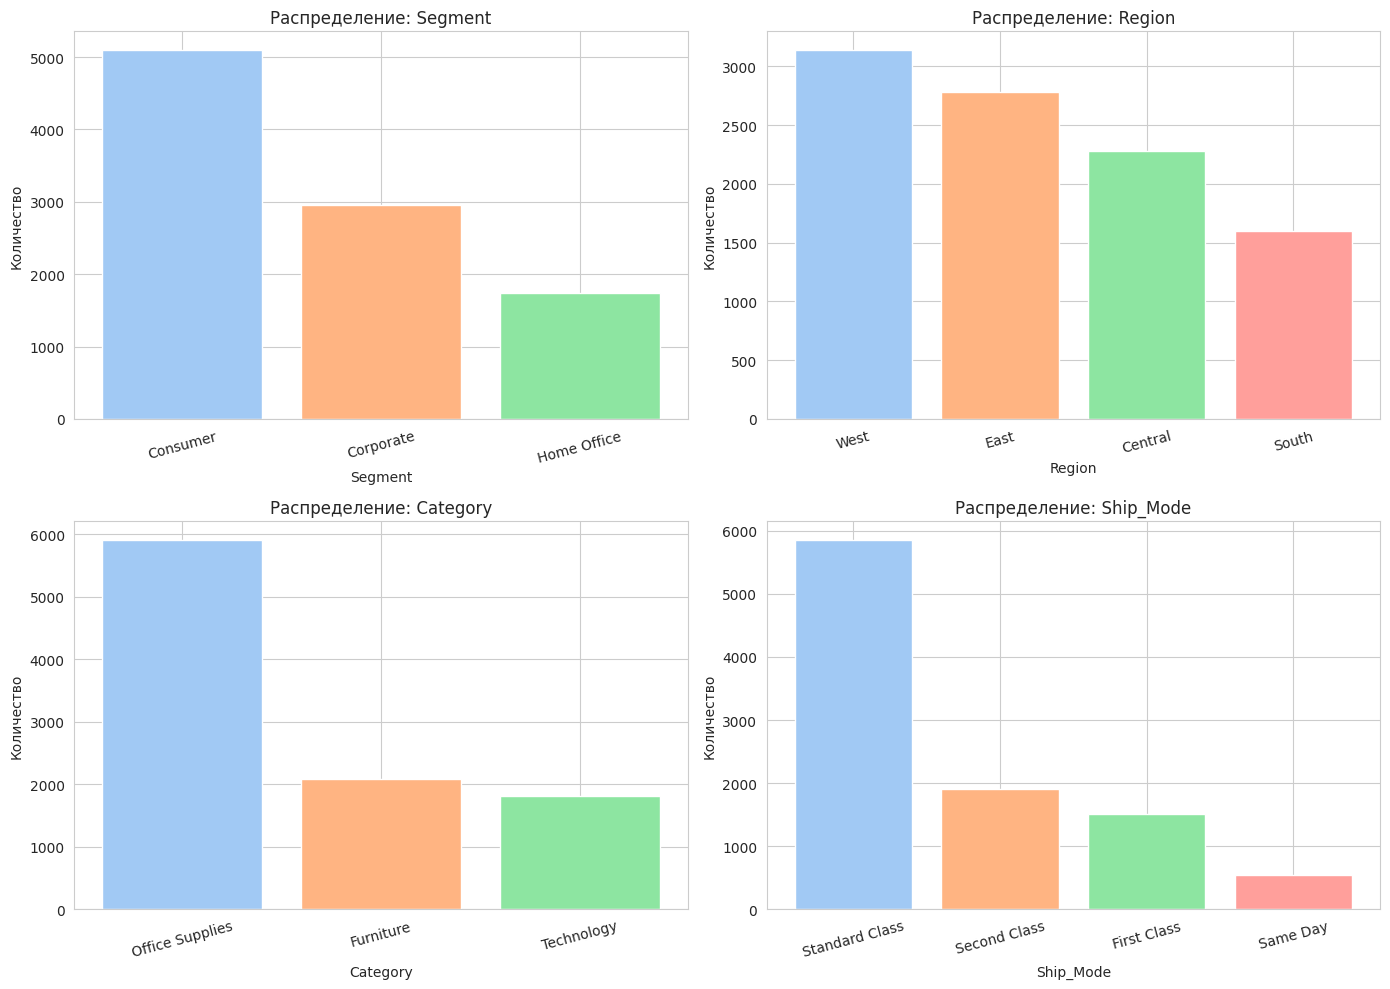

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), ['Segment', 'Region', 'Category', 'Ship_Mode']):
  counts = df[col].value_counts()
  ax.bar(counts.index, counts.values, color=sns.color_palette('pastel'))
  ax.set_title(f'Распределение: {col}')
  ax.set_xlabel(col)
  ax.set_ylabel('Количество')
  ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Результаты предварительного просмотра

Датасет содержит **9800 записей** и **18 столбцов**.  
2 числовых столбца - `Postal Code` (почтовый индекс) и `Sales` (сумма продажи).  

Остальные столбцы типа object.  

Есть пропуски в столбце `Postal Code`.

Также наблюдаются первые признаки выбросов: в частности, в столбце `Sales` min = 0.444, а max = 22638.48

Проанализировав таблицу c описательной статистикой категориальных признаков, можно сказать, что:


*   число заказов = 4922 (уникальных), а всего записей 9800 - то есть Order_ID где-то повторяются, что означает, что в одном заказе может быть несколько позиций товаров
*   наибольшее число товаров в одном заказе = 14
*   больше всего заказов с Ship_Mode = 'Standard Class'
*   самый лояльный клиент - William Brown - сделал 35 заказов
*   наибольшее число клиентов относится к сегменту Consumer
*   география заказов: 529 городов США и 49 штатов; больше всего заказов из Нью-Йорка и штата Калифорния; больше всего заказов - из западного региона.
*   самый частозаказываемый товар с Product_ID = OFF-PA-10001970
*   наибольшее число заказов - товары категории Office Supplies и подкатегории Binders
*   самый популярный товар среди клиентов - Staple envelope (скрепленный конверт)









# 3. Проверка на пропуски и аномалии + визуализация

Посчитаем пропуски в данных.

Количество пропусков по столбцам:
Postal_Code    11
dtype: int64


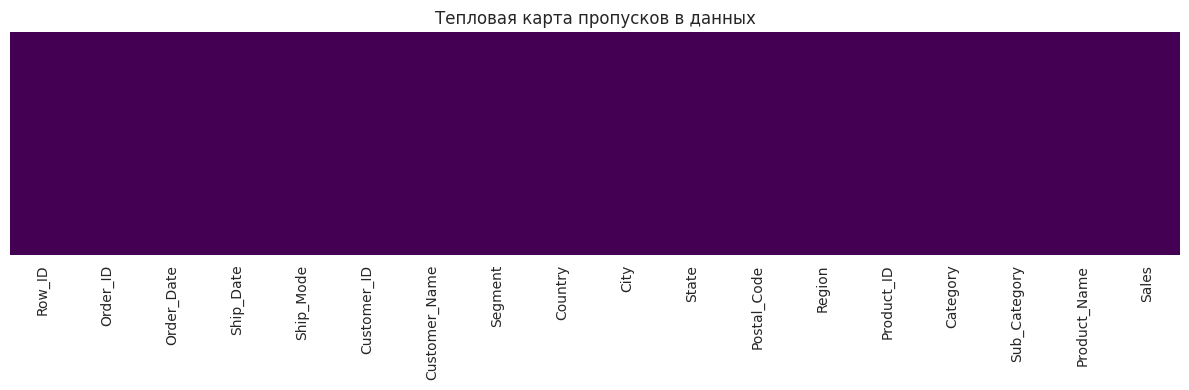

In [8]:
print("Количество пропусков по столбцам:")
missing = df.isnull().sum()
print(missing[missing > 0])

plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Тепловая карта пропусков в данных')
plt.tight_layout()
plt.show()

Из-за слишком малого числа пропусков в столбце Postal_Code на тепловой карте они не видны.

Проверка на полные дубликаты строк.

In [9]:
print("\n" + "=" * 60)
print("ПРОВЕРКА НА ДУБЛИКАТЫ")
print("=" * 60)

full_duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов строк: {full_duplicates}")


ПРОВЕРКА НА ДУБЛИКАТЫ
Количество полных дубликатов строк: 0


Дубликатов строк не обнаружено.

Пронализируем выбросы в столбце Sales.

АНАЛИЗ ВЫБРОСОВ (ПО СТОЛБЦУ SALES)
Столбец 'Sales':
  Q1 = 17.25, Q3 = 210.61, IQR = 193.36
  Нижняя граница (по IQR): -272.79
  Верхняя граница (по IQR): 500.64
  Выбросов по IQR: 1145 (11.68%)
  Минимум: 0.44, Максимум: 22638.48


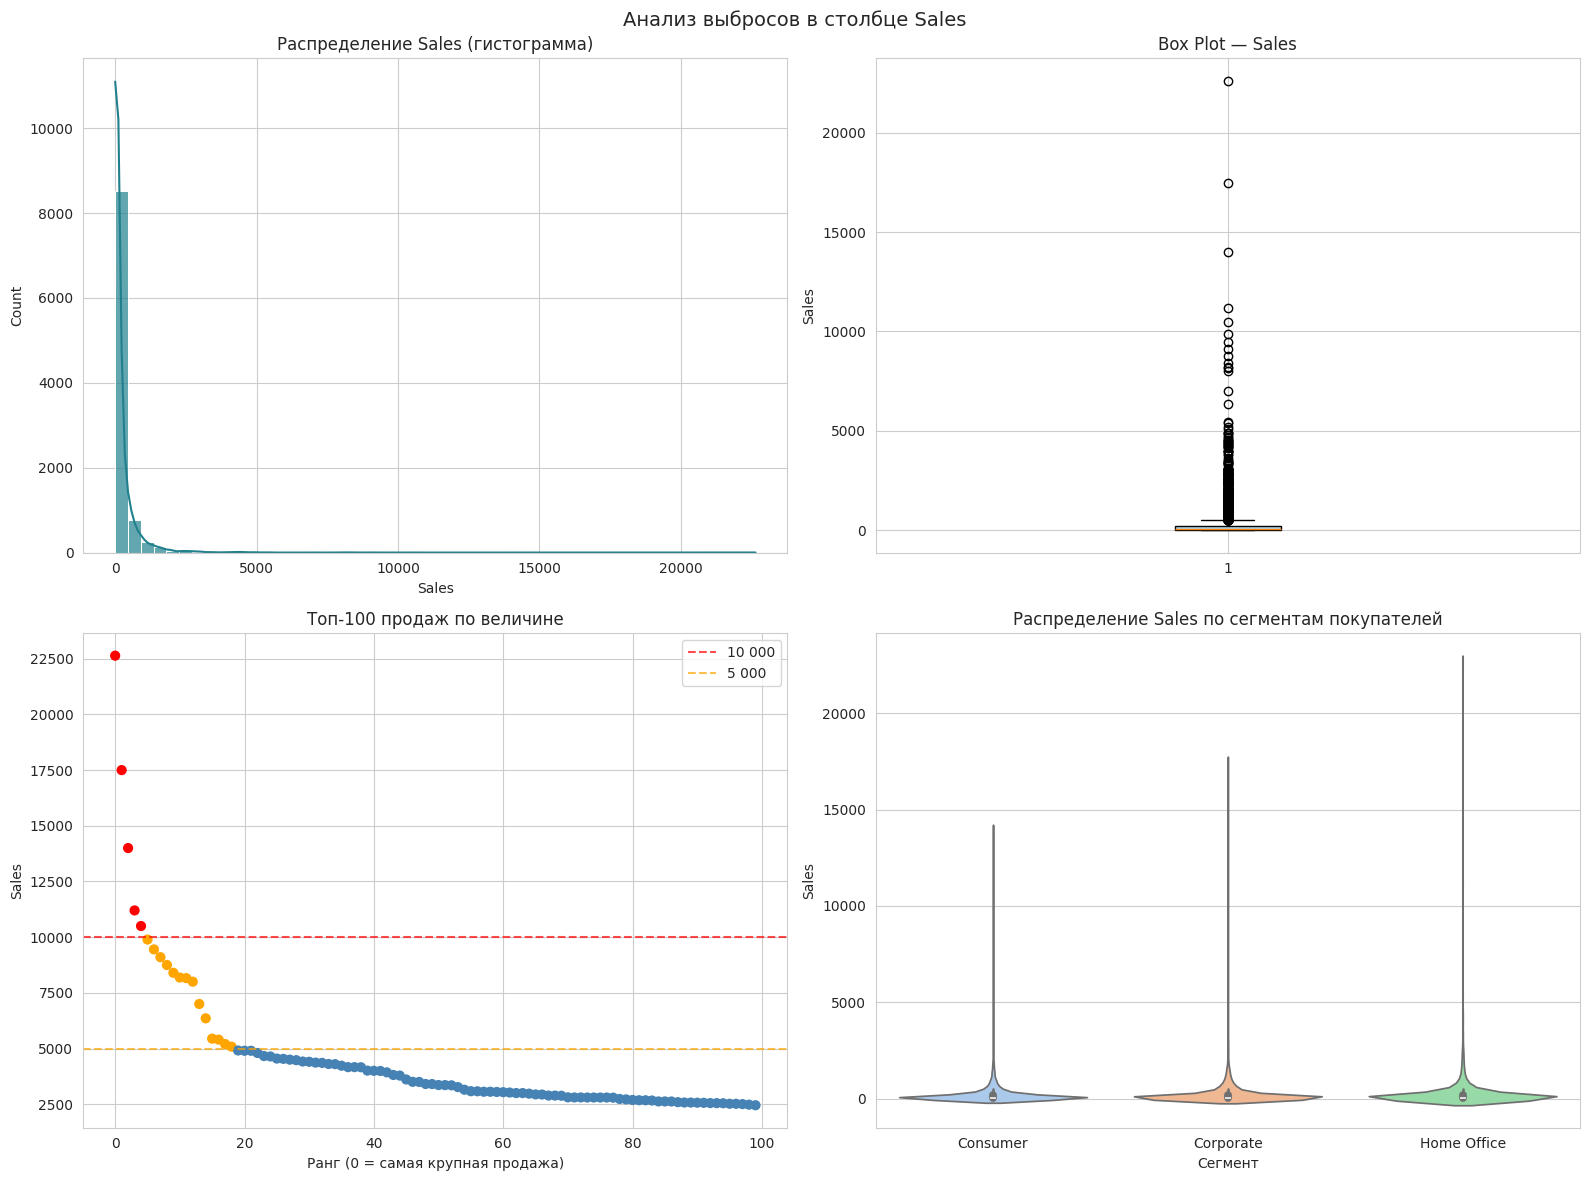


Записи с Sales > 10 000:


,Sales,Segment,Category,Sub_Category,Product_Name
2697,22638.480,Home Office,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...
6826,17499.950,Corporate,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier
8153,13999.960,Consumer,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier
2623,11199.968,Home Office,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier
4190,10499.970,Consumer,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier


In [10]:
print("=" * 60)
print("АНАЛИЗ ВЫБРОСОВ (ПО СТОЛБЦУ SALES)")
print("=" * 60)

col = 'Sales'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print(f"Столбец '{col}':")
print(f"  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"  Нижняя граница (по IQR): {lower_bound:.2f}")
print(f"  Верхняя граница (по IQR): {upper_bound:.2f}")
print(f"  Выбросов по IQR: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")
print(f"  Минимум: {df[col].min():.2f}, Максимум: {df[col].max():.2f}")

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Анализ выбросов в столбце Sales', fontsize=14)

# График 1: Гистограмма
sns.histplot(df[col], bins=50, kde=True, ax=axes[0, 0], color='#20808D', edgecolor='white', alpha=0.7)
axes[0, 0].set_title('Распределение Sales (гистограмма)')
axes[0, 0].set_xlabel('Sales')

# График 2: Box Plot
axes[0, 1].boxplot(df[col], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[0, 1].set_title('Box Plot — Sales')
axes[0, 1].set_ylabel('Sales')

# График 3: Топ-100 продаж
top100 = df[col].sort_values(ascending=False).head(100).reset_index(drop=True)
colors = ['red' if v > 10000 else 'orange' if v > 5000 else 'steelblue' for v in top100]
axes[1, 0].scatter(top100.index, top100.values, c=colors, s=40)
axes[1, 0].axhline(y=10000, color='red', linestyle='--', alpha=0.7, label='10 000')
axes[1, 0].axhline(y=5000, color='orange', linestyle='--', alpha=0.7, label='5 000')
axes[1, 0].set_title('Топ-100 продаж по величине')
axes[1, 0].set_xlabel('Ранг (0 = самая крупная продажа)')
axes[1, 0].set_ylabel('Sales')
axes[1, 0].legend()

# График 4: Sales по сегменту (violin plot)
sns.violinplot(data=df, x='Segment', y=col, ax=axes[1, 1], palette='pastel', inner='box')
axes[1, 1].set_title('Распределение Sales по сегментам покупателей')
axes[1, 1].set_xlabel('Сегмент')
axes[1, 1].set_ylabel('Sales')

plt.tight_layout()
plt.show()

print("\nЗаписи с Sales > 10 000:")
display(df[df[col] > 10000][['Sales', 'Segment', 'Category', 'Sub_Category', 'Product_Name']].sort_values('Sales', ascending=False))

Анализ столбца Sales с помощью межквартильного размаха (IQR) показал наличие выбросов. Всего их 1145 (11.68% от всех записей).

Верхняя граница для нормальных значений составляет 500.64, в то время как максимальное значение достигает 22638.48. Это свидетельствует о наличии очень крупных заказов.

Гистограмма и boxplot наглядно демонстрируют скошенное вправо распределение и наличие "уса" из выбросов.

Violin plot позволяет сравнить распределение Sales по сегментам покупателей. У всех трёх сегментов большинство заказов сосредоточено в нижнем ценовом диапазоне, однако Corporate и Home Office демонстрируют более длинные "хвосты" — то есть крупные единичные заказы у них встречаются чаще, чем у розничных покупателей (Consumer).

Scatter plot топ-100 продаж демонстрирует плавный убывающий ряд без резких
скачков: большинство крупных заказов находится в диапазоне 539–5000, ещё
около 14 - в диапазоне 5000–10000, и лишь 5 записей превышают 10000.
Эти 5 записей соответствуют реально дорогостоящим товарам: система
видеоконференций Cisco TelePresence (22 638 у.е.) и профессиональные копиры
Canon imageCLASS (11 000–17 500 у.е.) - стандартные позиции в B2B-сегменте.

**Вывод:** значения, формально определённые IQR как **выбросы**, представляют
собой обоснованные крупные заказы и **не требуют устранения.** Данные остаются
без изменений по столбцу Sales.

# 4. Очистка данных (заполнение пропусков и устранение аномалий)

В предыдущем разделе был сделан вывод о том, что данные, определенные как выбросы, на самом деле являются просто крупными заказами и не требуют устранения.



Заполним 11 пропусков в столбце Postal_Code + Преобразуем столбцы с датами в тип данных datetime.

In [11]:
print("Строки с пропуском в Postal_Code:")
display(df[df['Postal_Code'].isna()][['City', 'State', 'Region', 'Postal_Code']])

Строки с пропуском в Postal_Code:


,City,State,Region,Postal_Code
2234,Burlington,Vermont,East,NaN
5274,Burlington,Vermont,East,NaN
8798,Burlington,Vermont,East,NaN
9146,Burlington,Vermont,East,NaN
9147,Burlington,Vermont,East,NaN
9148,Burlington,Vermont,East,NaN
9386,Burlington,Vermont,East,NaN
9387,Burlington,Vermont,East,NaN
9388,Burlington,Vermont,East,NaN
9389,Burlington,Vermont,East,NaN


Postal Code: все 11 пропущенных значений принадлежат одному городу - Burlington, Vermont (регион East).

In [12]:
# Находим реальный индекс Burlington, VT из других источников в датасете
burlington_code = df[
    (df['City'] == 'Burlington') &
    (df['State'] == 'Vermont') &
    (df['Postal_Code'].notna())
]['Postal_Code'].unique()

print(f"\nПочтовые индексы Burlington, Vermont в датасете: {burlington_code}")

# Если в датасете нет ни одной строки Burlington с индексом -
# используем официальный индекс города Burlington, VT = 5401
real_code = burlington_code[0] if len(burlington_code) > 0 else 5401

print(f"Используем индекс: {int(real_code)}")

df['Postal_Code'] = df['Postal_Code'].fillna(real_code)

print(f"\nПропуски в Postal_Code после заполнения: {df['Postal_Code'].isna().sum()}")


Почтовые индексы Burlington, Vermont в датасете: []
Используем индекс: 5401

Пропуски в Postal_Code после заполнения: 0


Вместо моды по региону используем реальный почтовый индекс этого города: 5401.

In [13]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date']  = pd.to_datetime(df['Ship_Date'],  dayfirst=True)
print("\nТипы дат после преобразования:")
print(df[['Order_Date', 'Ship_Date']].dtypes)


Типы дат после преобразования:
Order_Date    datetime64[ns]
Ship_Date     datetime64[ns]
dtype: object


Даты: столбцы Order_Date и Ship_Date преобразованы из строк в формат datetime - это необходимо для генерации признаков на следующем шаге.

# 5. Генерация новых признаков + кодирование категориальных признаков

In [14]:
df['Delivery_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Year'] = df['Order_Date'].dt.year
print("Новые признаки созданы:")
print(df[['Delivery_Days', 'Order_Month', 'Order_Year']].describe().round(2))


Новые признаки созданы:
       Delivery_Days  Order_Month  Order_Year
count        9800.00      9800.00     9800.00
mean            3.96         7.82     2016.72
std             1.75         3.28        1.12
min             0.00         1.00     2015.00
25%             3.00         5.00     2016.00
50%             4.00         9.00     2017.00
75%             5.00        11.00     2018.00
max             7.00        12.00     2018.00


Новые признаки:

Delivery Days - количество дней между датой заказа и датой отгрузки. Характеризует скорость сервиса.

Order Month - месяц заказа. Позволяет выявить сезонность продаж.

Order Year - год заказа (вспомогательный временной признак).

Можно сделать выводы:

*   Среднее время доставки - практически 4 дня, максимальное - 7 дней.
*   В датасете собраны данные о заказах за 2015-2018 гг.

В признаке Delivery_Days видим значения ноль. Проверим, скорее всего это доставка Same_Day.

In [15]:
zero_delivery = df[df['Delivery_Days'] == 0]
print(f"Записей с Delivery Days = 0: {len(zero_delivery)}")
print()
print("Распределение по Ship Mode:")
print(zero_delivery['Ship_Mode'].value_counts())

Записей с Delivery Days = 0: 514

Распределение по Ship Mode:
Ship_Mode
Same Day    514
Name: count, dtype: int64


Да, гипотеза подтвердилась.

Визуализация новых признаков (их распределение и динамика).

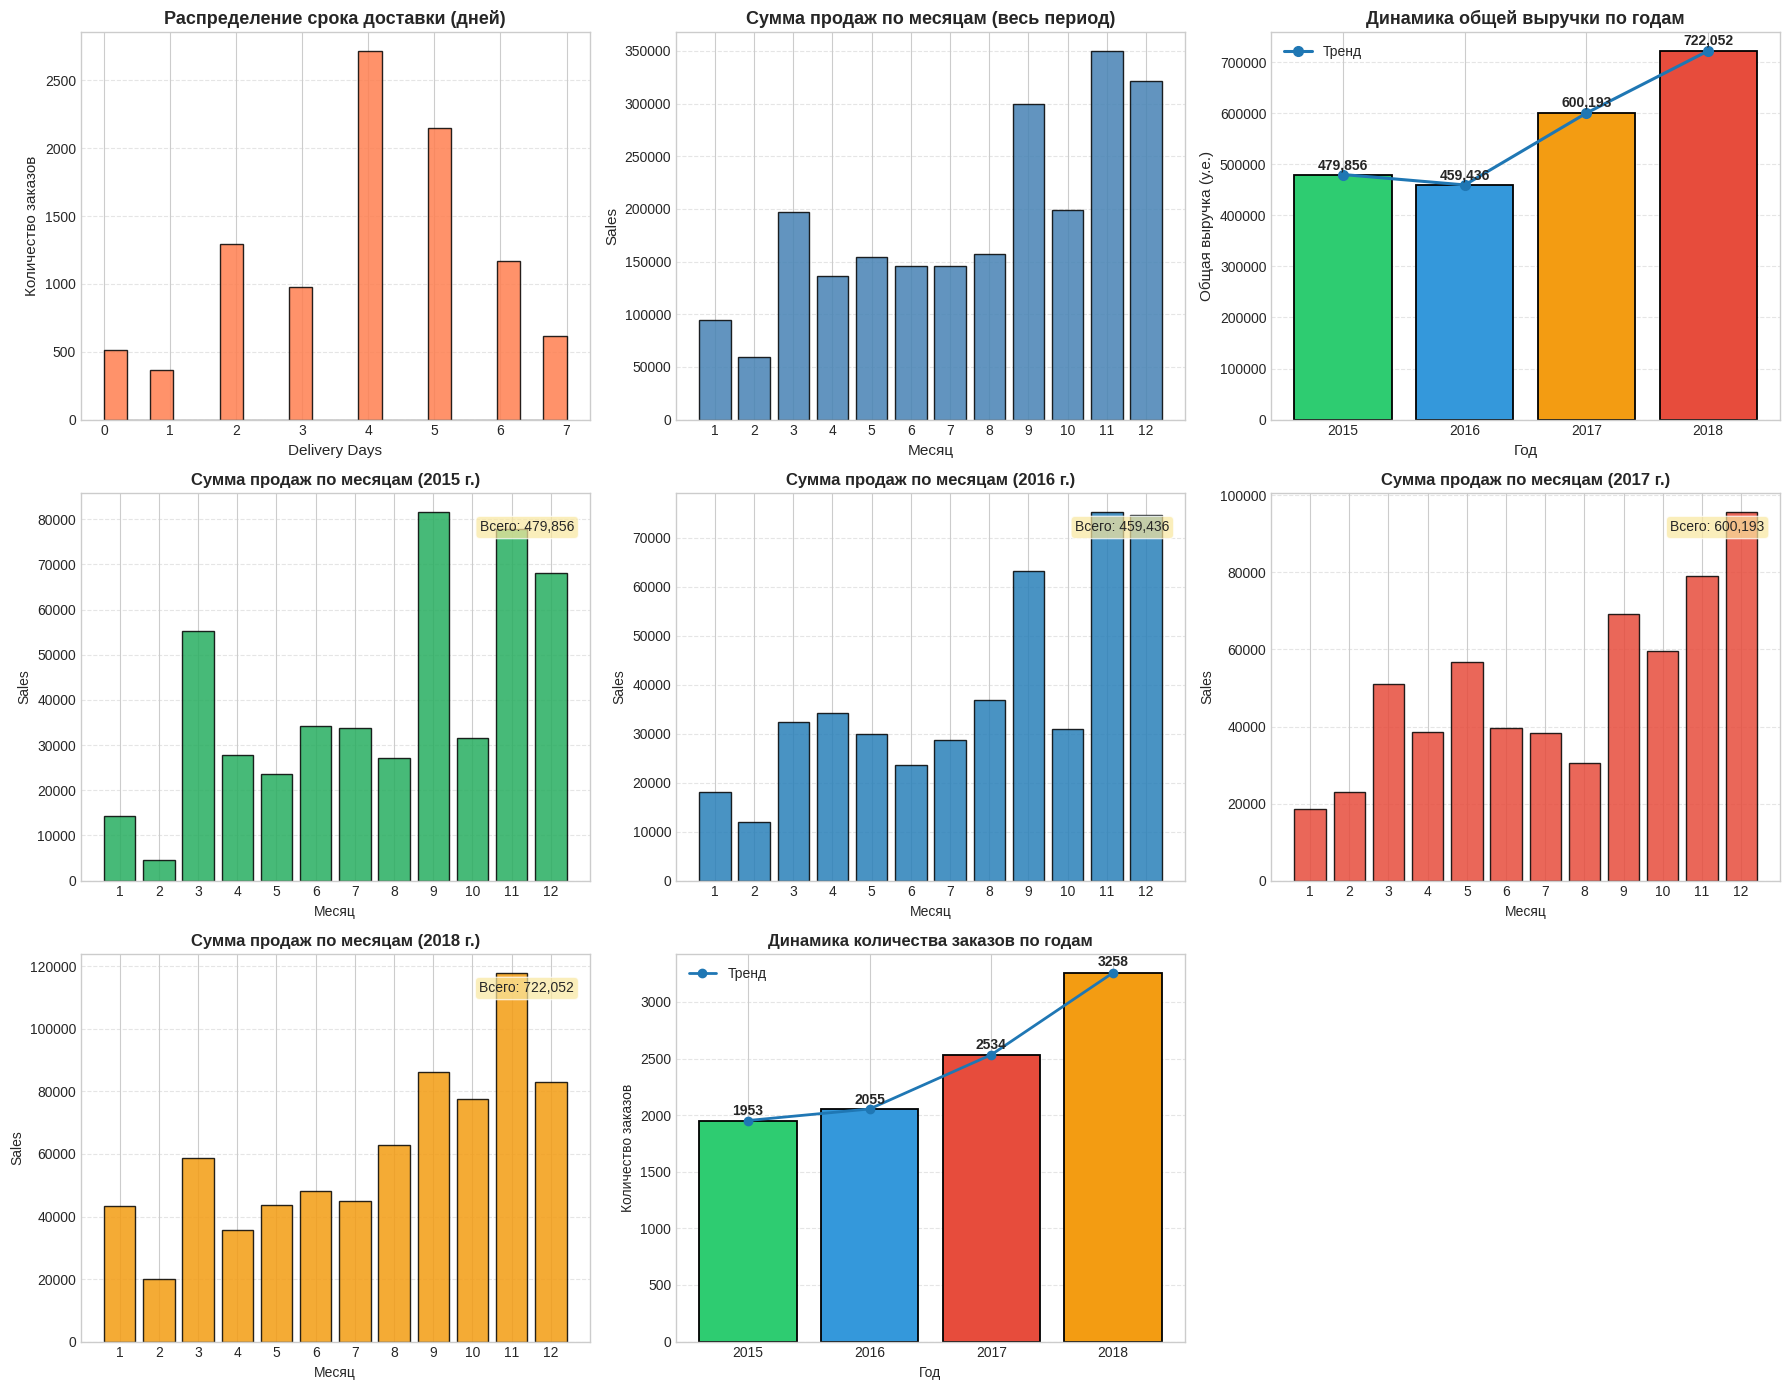

In [16]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 14))

# 1. Распределение Delivery_Days
ax1 = plt.subplot(3, 3, 1)
ax1.hist(df['Delivery_Days'], bins=20, color='#ff7f50', edgecolor='black', alpha=0.85)
ax1.set_title('Распределение срока доставки (дней)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Delivery Days', fontsize=11)
ax1.set_ylabel('Количество заказов', fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# 2. Сумма продаж по месяцам
ax2 = plt.subplot(3, 3, 2)
monthly_total = df.groupby('Order_Month')['Sales'].sum()
bars = ax2.bar(monthly_total.index, monthly_total.values, color='#4682B4', edgecolor='black', alpha=0.85)
ax2.set_title('Сумма продаж по месяцам (весь период)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Месяц', fontsize=11)
ax2.set_ylabel('Sales', fontsize=11)
ax2.set_xticks(range(1, 13))
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# 3. Выручка по годам
ax3 = plt.subplot(3, 3, 3)
sales_by_year = df.groupby('Order_Year')['Sales'].sum()
colors_year_bar = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax3.bar(sales_by_year.index, sales_by_year.values, color=colors_year_bar, edgecolor='black', linewidth=1.3)
for bar, val in zip(bars, sales_by_year.values):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01, f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_title('Динамика общей выручки по годам', fontsize=13, fontweight='bold')
ax3.set_xlabel('Год', fontsize=11)
ax3.set_ylabel('Общая выручка (у.е.)', fontsize=11)
ax3.set_xticks(sales_by_year.index)
ax3.grid(axis='y', linestyle='--', alpha=0.5)
# Линия тренда
x = list(sales_by_year.index)
y = list(sales_by_year.values)
ax3.plot(x, y, marker='o', linewidth=2.2, markersize=7, label='Тренд')
ax3.legend()

# 4–7. Продажи по месяцам для каждого года
years = [2015, 2016, 2017, 2018]
colors = ['#27ae60', '#2980b9', '#e74c3c', '#f39c12']
for idx, year in enumerate(years):
    ax = plt.subplot(3, 3, 4 + idx)
    df_year = df[df['Order_Year'] == year]
    monthly_by_year = (df_year.groupby('Order_Month')['Sales'].sum())
    bars = ax.bar(monthly_by_year.index, monthly_by_year.values, color=colors[idx], edgecolor='black', alpha=0.85)
    ax.set_title(f'Сумма продаж по месяцам ({year} г.)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Месяц', fontsize=10)
    ax.set_ylabel('Sales', fontsize=10)
    ax.set_xticks(range(1, 13))
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    total_sales = df_year['Sales'].sum()
    ax.text(0.97, 0.93, f'Всего: {total_sales:,.0f}', transform=ax.transAxes, ha='right', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='#f9e79f', alpha=0.7))

# 8. Динамика количества заказов
ax8 = plt.subplot(3, 3, 8)
orders_by_year = df.groupby('Order_Year').size()
colors_year = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
bars = ax8.bar(orders_by_year.index, orders_by_year.values, color=colors_year, edgecolor='black', linewidth=1.3)
for bar, count in zip(bars, orders_by_year.values):
    ax8.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01, f'{int(count)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax8.set_title('Динамика количества заказов по годам', fontsize=12, fontweight='bold')
ax8.set_xlabel('Год')
ax8.set_ylabel('Количество заказов')
ax8.set_xticks(orders_by_year.index)
ax8.grid(axis='y', linestyle='--', alpha=0.5)
# Линия тренда
x = list(orders_by_year.index)
y = list(orders_by_year.values)
ax8.plot(x, y, marker='o', linewidth=2, markersize=6, label='Тренд')
ax8.legend()
plt.tight_layout()
plt.show()

Проанализировав графики, можно заключить, что:

*   Заказ доставляют в среднем за **4 дня.**
*   **Наибольшая выручка** традиционно достигается **в ноябре, декабре и сентябре.**
*   Динамика выручки по годам демонстрирует восходящий тренд с небольшим спадом в 2016 г., **в 2018 году составив более 722 тыс. у.е.**
*   Количество заказов также растет с течением времени, **достигая в 2018 году отметки в более 3,2 тыс. заказов.**



In [17]:
# OHE-кодирование
df_encoded = pd.get_dummies(df, columns=['Segment', 'Region', 'Ship_Mode'], drop_first=False)

ohe_cols = [c for c in df_encoded.columns
            if c.startswith(('Segment_', 'Region_', 'Ship_Mode_'))]
print(f"\nOHE-столбцы ({len(ohe_cols)} шт.):")
print(ohe_cols)
display(df_encoded[ohe_cols].head(3))

# Бинаризация Category
df_encoded['Is_Technology'] = (df_encoded['Category'] == 'Technology').astype(int)

print("\nРаспределение бинарного признака 'Is_Technology':")
print(df_encoded['Is_Technology'].value_counts())
print(f"  1 - Technology, 0 - другие категории")


OHE-столбцы (11 шт.):
['Segment_Consumer', 'Segment_Corporate', 'Segment_Home Office', 'Region_Central', 'Region_East', 'Region_South', 'Region_West', 'Ship_Mode_First Class', 'Ship_Mode_Same Day', 'Ship_Mode_Second Class', 'Ship_Mode_Standard Class']


,Segment_Consumer,Segment_Corporate,Segment_Home Office,Region_Central,Region_East,Region_South,Region_West,Ship_Mode_First Class,Ship_Mode_Same Day,Ship_Mode_Second Class,Ship_Mode_Standard Class
0,True,False,False,False,False,True,False,False,False,True,False
1,True,False,False,False,False,True,False,False,False,True,False
2,False,True,False,False,False,False,True,False,False,True,False



Распределение бинарного признака 'Is_Technology':
Is_Technology
0    7987
1    1813
Name: count, dtype: int64
  1 - Technology, 0 - другие категории


OHE-кодирование: применено к столбцам Segment, Region, Ship Mode. Каждое уникальное значение преобразуется в отдельный бинарный столбец.

Бинаризация: создан признак Is_Technology - равен 1, если категория товара «Technology», иначе 0.

# 6. Корреляционная матрица



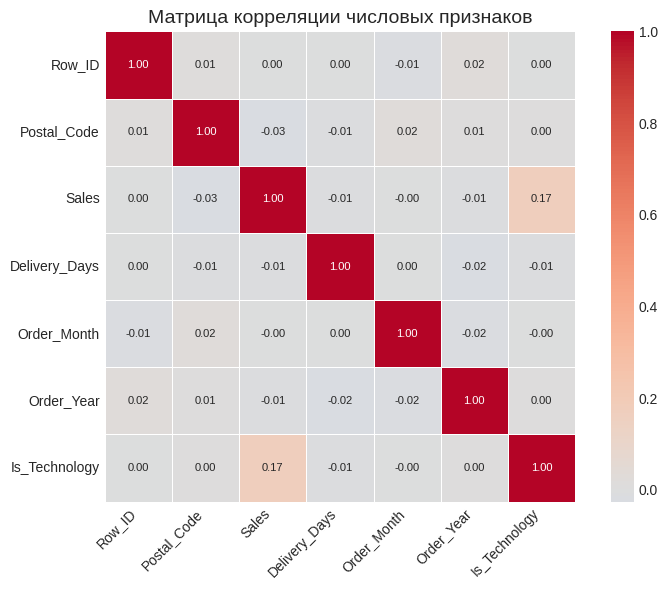

Корреляция признаков с целевой переменной Sales:
Is_Technology    0.172
Postal_Code      0.026
Order_Year       0.011
Delivery_Days    0.006
Row_ID           0.001
Order_Month      0.000
Name: Sales, dtype: float64


In [18]:
numeric_df = df_encoded.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Матрица корреляции числовых признаков', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Корреляция признаков с целевой переменной Sales:")
corr_with_sales = corr_matrix['Sales'].drop('Sales').abs().sort_values(ascending=False)
print(corr_with_sales.round(3))

Матрица корреляции показывает линейную зависимость между числовыми
признаками. Значения близкие к 1 или -1 означают сильную связь (не учитываем главную диагональ матрицы), близкие к 0 - слабую.

Из таблицы корреляций с Sales видно, что бинарный признак Is_Technology показывает наибольшую корреляцию с целевой переменной (коэффициент корреляции = 0.17 - слабая линейная связь). Остальные признаки не имеют явной корреляции с Sales, что говорит об отсутсвии линейной зависимости между географией, сроком доставки и датой продажи.

# 7. Стандартизация и нормализация данных

Нормализация Min-Max [0, 1]:


,Sales_normalized,Delivery_Days_normalized,Order_Month_normalized
count,9800.000,9800.000,9800.000
mean,0.010,0.566,0.620
std,0.028,0.250,0.298
min,0.000,0.000,0.000
25%,0.001,0.429,0.364
50%,0.002,0.571,0.727
75%,0.009,0.714,0.909
max,1.000,1.000,1.000



Стандартизация Z-score (mean ≈ 0, std ≈ 1):


,Sales_standardized,Delivery_Days_standardized,Order_Month_standardized
count,9800.000,9800.000,9800.000
mean,-0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-0.368,-2.264,-2.078
25%,-0.341,-0.549,-0.859
50%,-0.281,0.022,0.360
75%,-0.032,0.594,0.969
max,35.758,1.737,1.274


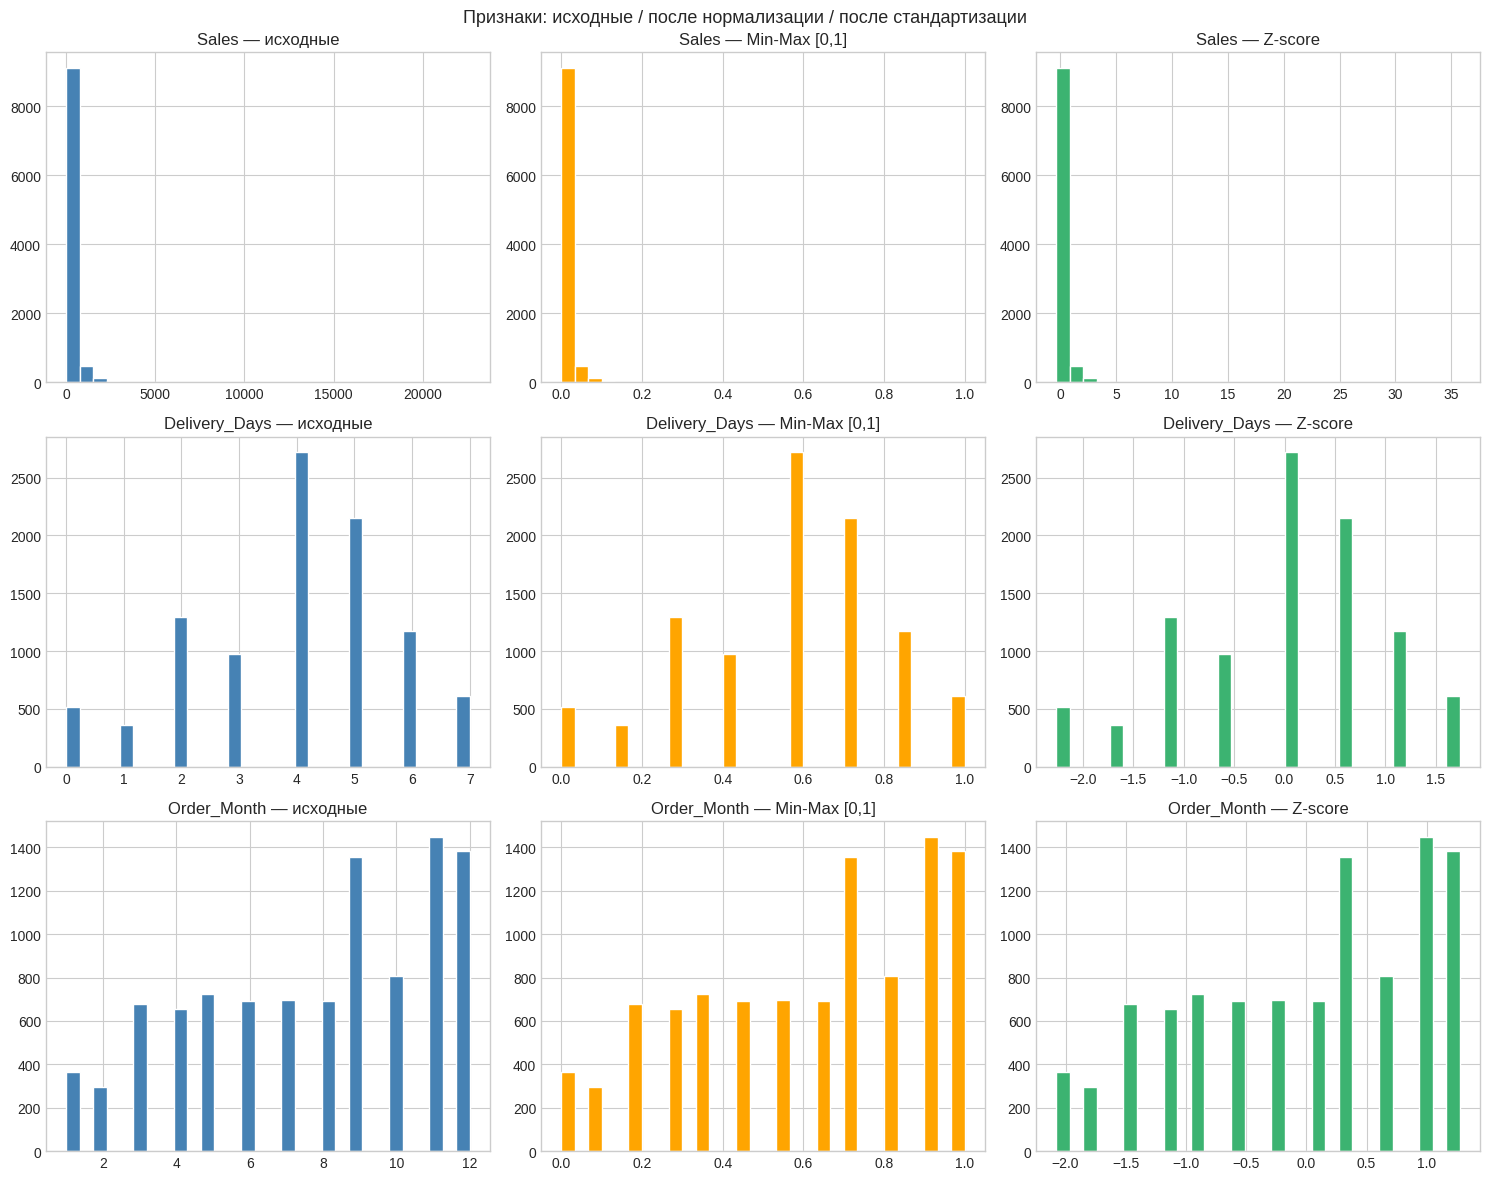

Проверка стандартизации Sales:
  mean = -0.00000  (должно быть ≈ 0)
  std  = 1.00000   (должно быть ≈ 1)


In [19]:
numeric_cols = ['Sales', 'Delivery_Days', 'Order_Month']

# Нормализация Min-Max
df_normalized = df_encoded.copy()
for col in numeric_cols:
    col_min = df_normalized[col].min()
    col_max = df_normalized[col].max()
    df_normalized[col + '_normalized'] = (df_normalized[col] - col_min) / (col_max - col_min)
print("Нормализация Min-Max [0, 1]:")
display(df_normalized[[c + '_normalized' for c in numeric_cols]].describe().round(3))

# Стандартизация Z-score
df_standardized = df_encoded.copy()
for col in numeric_cols:
    col_mean = df_standardized[col].mean()
    col_std  = df_standardized[col].std()
    df_standardized[col + '_standardized'] = (df_standardized[col] - col_mean) / col_std
print("\nСтандартизация Z-score (mean ≈ 0, std ≈ 1):")
display(df_standardized[[c + '_standardized' for c in numeric_cols]].describe().round(3))

# Визуализация до и после
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Признаки: исходные / после нормализации / после стандартизации', fontsize=13)
colors = ['steelblue', 'orange', 'mediumseagreen']
for i, col in enumerate(numeric_cols):
    axes[i][0].hist(df_encoded[col], bins=30, color=colors[0], edgecolor='white')
    axes[i][0].set_title(f'{col} — исходные')
    axes[i][1].hist(df_normalized[col + '_normalized'], bins=30, color=colors[1], edgecolor='white')
    axes[i][1].set_title(f'{col} — Min-Max [0,1]')
    axes[i][2].hist(df_standardized[col + '_standardized'], bins=30, color=colors[2], edgecolor='white')
    axes[i][2].set_title(f'{col} — Z-score')
plt.tight_layout()
plt.show()

# Проверка
print("Проверка стандартизации Sales:")
print(f"  mean = {df_standardized['Sales_standardized'].mean():.5f}  (должно быть ≈ 0)")
print(f"  std  = {df_standardized['Sales_standardized'].std():.5f}   (должно быть ≈ 1)")


Для подготовки числовых признаков к машинному обучению применены два метода масштабирования:

**Нормализация (Min-Max Scaling):**  
Формула: `x_new = (x - x_min) / (x_max - x_min)`  
Все значения приводятся к диапазону [0, 1]. Используется, когда алгоритм чувствителен к масштабу (например, KNN, нейронные сети).

**Стандартизация (Z-score Standardization):**  
Формула: `x_new = (x - mean) / std`  
Признак центрируется (mean ≈ 0) и масштабируется по стандартному отклонению (std ≈ 1). Подходит для алгоритмов, предполагающих нормальное распределение (например, линейная регрессия, SVM).


# 8. Выводы



## Датасет
- 9 800 записей, 18 признаков, данные за период 2015–2018 гг.
- Единственный столбец с пропусками - `Postal_Code` (11 пропусков, Burlington VT) - заполнен реальным почтовым индексом 5401
- Дубликатов строк не обнаружено

## Sales распределение
- Сильное смещение вправо: медиана ~54 доллара, среднее значение ~230 долларов, максимальное значение ~22 600 долларов
- 11,7% записей помечены IQR как выбросы - но это просто крупные заказы, а не ошибки

## Доставка
- Среднее время доставки 4 дня, максимальное - 7 дней

## Сезонность & Тренды
- Месяцы с самой высокой выручкой: **Сентябрь, Ноябрь, Декабрь**
- Выручка выросла с ~$484 тыс. (2015) до ~ $722 тыс. (2018)
- Объем заказов также неуклонно рос

## Корреляции
- Нет сильной линейной корреляции с `Sales`
- Самый высокий показатель: `Is_Technology` (r = 0,17) - технологические продукты, как правило, имеют более высокую стоимость заказа
- Продажи, по-видимому, зависят от нелинейных факторов (тип продукта, комбинации клиентских сегментов).

## Генерация признаков
- Созданы новые признаки: `Delivery_Days`, `Order_Month`, `Order_Year`
- OHE-кодирование: `Segment`, `Region`, `Ship_Mode`
- Бинарный признак: `Is_Technology`
- Применена нормализация Min-Max и стандартизация для обеспечения готовности к ML